<h2 style="text-align: center;">НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ 
<br/>МОСКОВСКИЙ ЭНЕРГЕТИЧЕСКИЙ ИНСТИТУТ</h2>
</br>
<h3 style="text-align: center;">Кафедра Паровых и Газовых Турбин</h3>

</br>
</br>
</br>
</br>
</br>

<h1 style="text-align: center;">Курсовая работа по курсу:</h1>
<h1 style="text-align: center;">«Паровые и газовые турбины»</h1>

</br>
</br>
</br>
</br>
</br>

<h5 style="text-align: right;">Студент: Салабай Валерий Романович</h5>
<h5 style="text-align: right;">Группа: ФПэ-01-22</h5>

</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>

<h5 style="text-align: center;">Москва 2025</h5>

## Вариант №8

### $\space$ Дано:
* $P_0 = 24,5\space МПа $ - Давление на входе в турбину
* $t_0 = 550 ^\circ C$ -  Температура на входе в турбину
* $P_{пп} = 4 \space МПа$ -  Давление промежуточного перегрева
* $t_{пп} = 550 ^\circ C$ -  Температура промежуточного перегрева
* $P_{к} = 3,1 \space кПа$ -  Давление в конденсаторе
* $t_{п.в.} = 278^\circ C$ -  Температура питательной воды

* $N_{э} = 570 \space МВт$ -  Электрическая мощность ПТУ
* Z = 8 -  Количество отборов

In [303]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Построение процесса расширения пара в турбине. Определение расходов пара на входе в турбину $G_0$ и в конденсатор $G_к$.

In [305]:
import stproverka1 as srd
import graphics as gr

In [306]:
# Константы единиц измерения
MPa = 10 ** 6
kPa = 10 ** 3
MW = 10 ** 6

In [307]:
def create_turbine_model():
    return srd.Steam_Rashod(
        p_o=24.5 * MPa,
        t_o=550, 
        p_nn=4 * MPa, 
        t_nn=550,
        p_k=3.1 * kPa,
        effect_oi=0.85,
        effect_mex=0.9925,
        effect_eg=0.985,
        n=570 * MW,
        t_nv=278
    )

def calculate_steam_flows(turbine):
    return turbine.calc_rashod()

def print_results(g0, gk):
    print(f"Расход свежего пара перед турбиной G_o = {g0:.2f} кг/с")
    print(f"Расход пара в конденсаторе G_k = {gk:.2f} кг/с")


turbine = create_turbine_model()
g0, gk = calculate_steam_flows(turbine)
print_results(g0, gk)

Расход свежего пара перед турбиной G_o = 474.98 кг/с
Расход пара в конденсаторе G_k = 315.57 кг/с


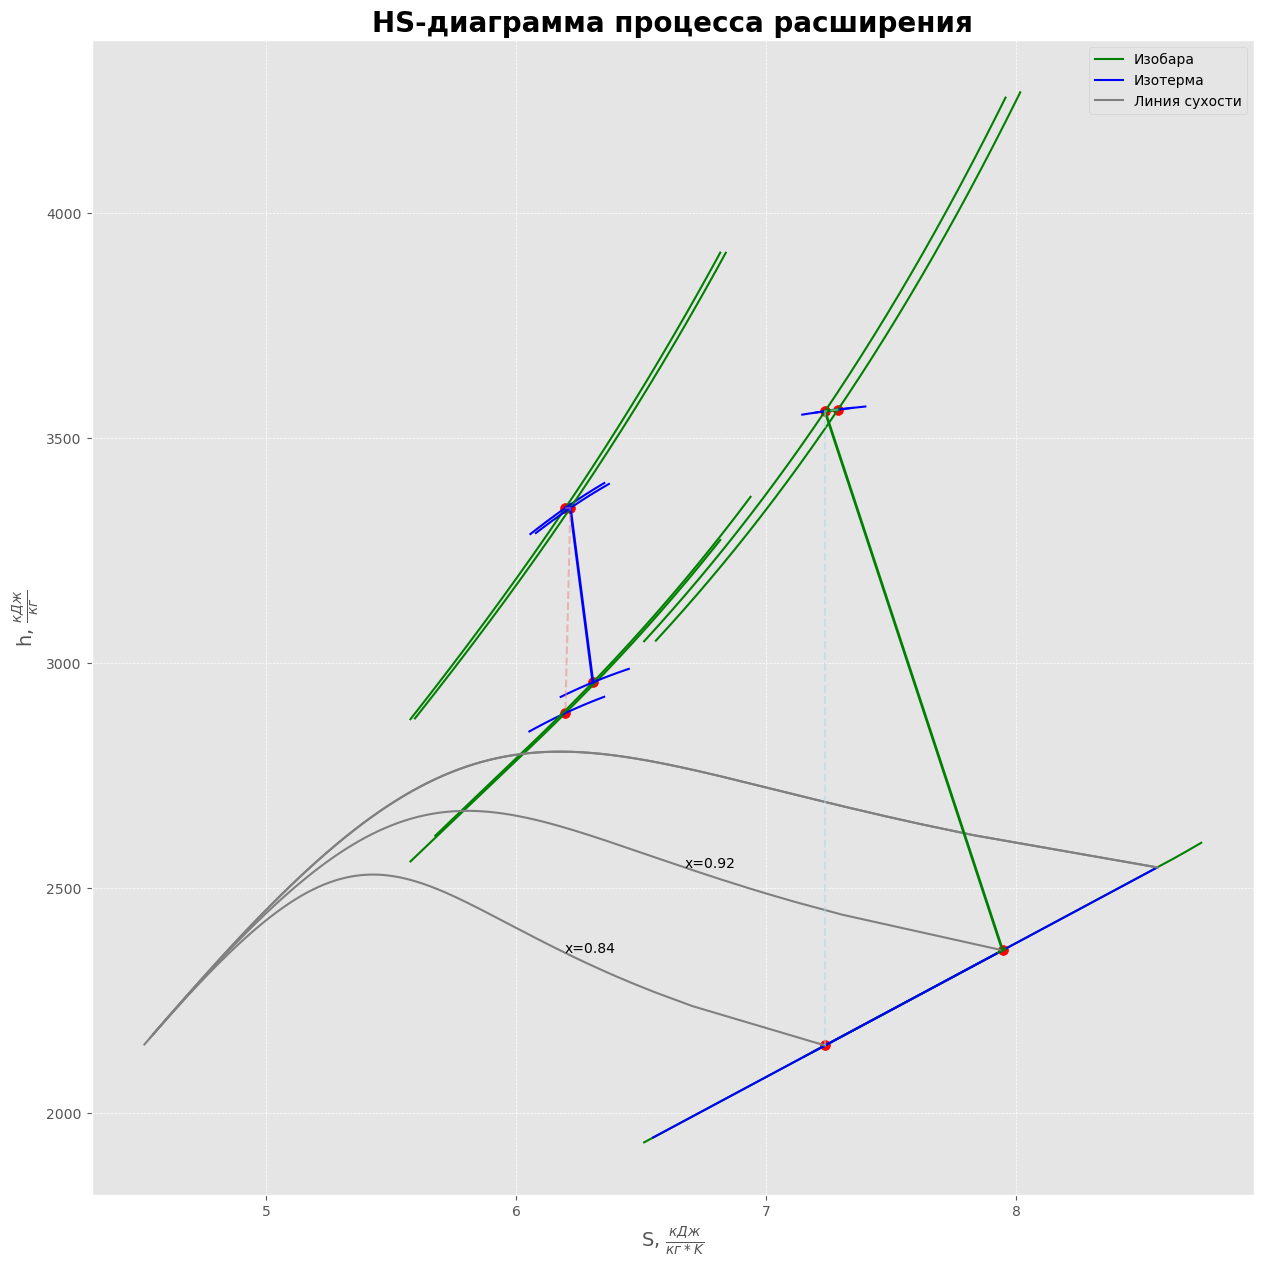

In [308]:
import matplotlib.pyplot as plt
from typing import List

def configure_plot_style():
    """Стиль графиков"""
    plt.style.use('ggplot')

def create_figure():
    return plt.subplots(1, 1, figsize=(15, 15))

def get_process_points(turbine):
    """Возвращает списки точек для всех процессов"""
    return [
        [turbine.point_o_teor, turbine.point_o, turbine.point_1],
        [turbine.point_nn_teor, turbine.point_nn, turbine.point_k],
        [turbine.point_o_teor, turbine.point_o, turbine.point_1_teor], 
        [turbine.point_nn_teor, turbine.point_nn, turbine.point_k_teor]
    ]

def plot_diagram(ax, turbine):
    """Строит HS-диаграмму с процессами"""
    # Все точки для диаграммы
    all_points = [
        turbine.point_o_teor, turbine.point_o, turbine.point_1_teor, turbine.point_1,
        turbine.point_nn_teor, turbine.point_nn, turbine.point_k, turbine.point_k_teor
    ]
    
    # Построение диаграммы
    gr.plot_hs_diagram(ax, points=all_points)
    
    # Параметры для каждого процесса
    processes = get_process_points(turbine)
    styles = [
        {'color': 'blue', 'linestyle': '-', 'linewidth': 2},
        {'color': 'green', 'linestyle': '-', 'linewidth': 2},
        {'color': 'lightcoral', 'linestyle': '--', 'alpha': 0.5},
        {'color': 'lightblue', 'linestyle': '--', 'alpha': 0.5}
    ]
    
    # Построение всех процессов
    for points, style in zip(processes, styles):
        gr.plot_process(ax, points=points, **style)

def configure_axes(ax):
    """Оформление осей"""
    ax.set_title('HS-диаграмма процесса расширения', 
                fontsize=20, 
                fontweight='bold')
    ax.grid(True, which='both', 
           linestyle='--', 
           linewidth=0.5)

def build_hs_diagram(turbine):
    """Основная функция построения диаграммы"""
    configure_plot_style()
    fig, ax = create_figure()
    plot_diagram(ax, turbine)
    configure_axes(ax)
    plt.show()
    
build_hs_diagram(turbine)

# Задание 2: Проведение расчета регулирующей ступени и определение зависимости $η_о$$_л$ от $U/$$с_ф$. Диапазон варьируемого диаметра. Обоснованно выбрать вариант исполнения регулирующей ступени для проектирования ЦВД в рамках заданного диапазона

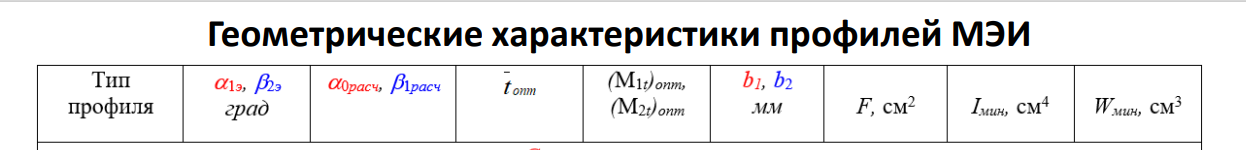

# Сопловая решетка

# Рабочая решетка

In [315]:
from watersteam import WaterSteam
import numpy as np
import determination_of_turbinemy_parameters as tr
import matplotlib.pyplot as plt 

import pandas as pd

# Поиск оптимального теплоперепада

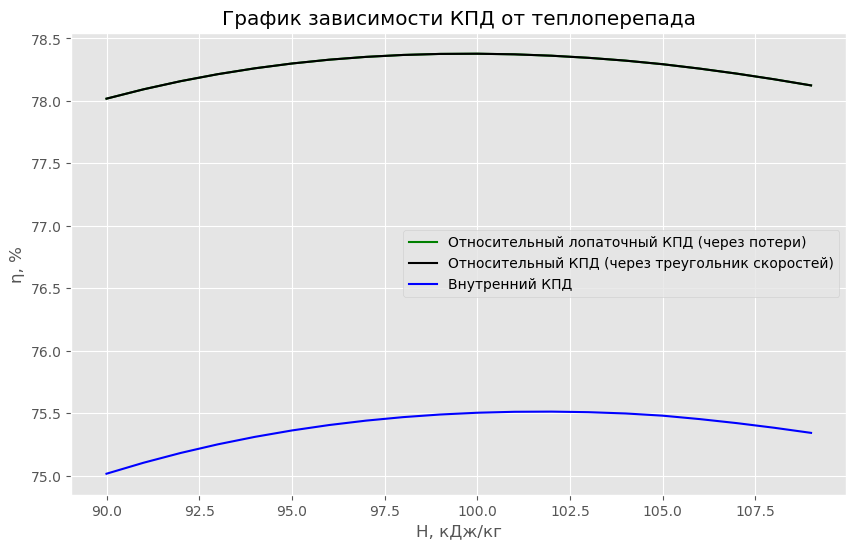

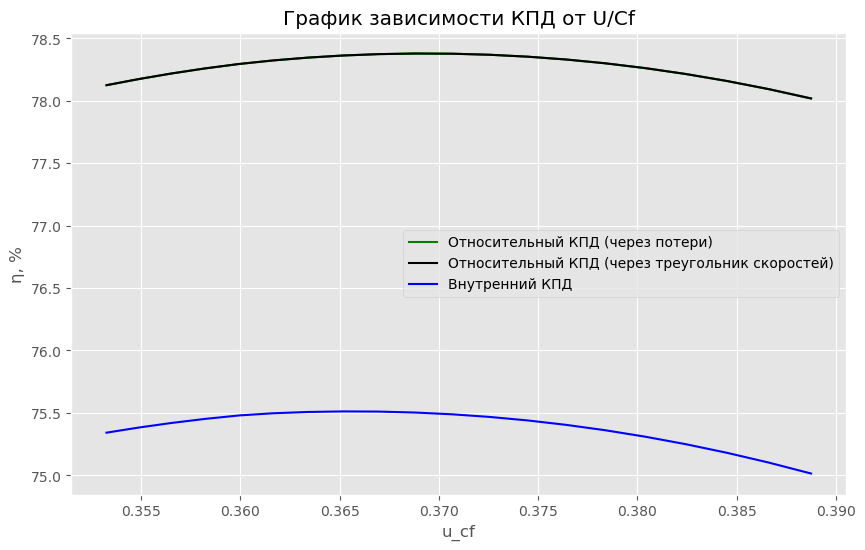

(None,)

In [317]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

def initialize_parameters() -> Tuple[List[float], List[float], List[float], List[float]]:
    """Инициализирует пустые массивы для хранения результатов"""
    return [], [], [], []

def calculate_turbine_parameters(turbine: object, g_0: float, H_values: np.ndarray) -> Tuple[
    List[float], List[float], List[float], List[float], np.ndarray]:
    """
    Выполняет расчет параметров турбины для диапазона теплоперепадов
    Возвращает:
        efficiency_loss, efficiency_velocity, efficiency_internal, u_cf, H_values
    """
    efficiency_loss, efficiency_velocity, efficiency_internal, u_cf = initialize_parameters()
    
    for H in H_values:
        lop = tr.RegularTurbin(
            tochka_o=turbine.point_o,
            n=50,
            d=1.05,
            H_o=H,
            ro=0.05,
            G=g0,
            k=1.33
        )
        lop.calc_sopl_lop(b_1=52, alpha_1_e=17, t_1opt=0.7)
        lop.calc_for_find_koef_rab_lop(pere=0.003)
        lop.calc_rab_lop(b_2=30.2, t_opt_2=0.4)
        
        eff_ol_loss, eff_ol_velocity = lop.calc_eff(xi_vs=0)
        N_i, kpd_oi = lop.calc_int_power(z=10, i=4)
        
        efficiency_loss.append(eff_ol_loss * 100)
        efficiency_velocity.append(eff_ol_velocity * 100)
        efficiency_internal.append(kpd_oi * 100)
        u_cf.append(lop.u_c_f)
    
    return efficiency_loss, efficiency_velocity, efficiency_internal, u_cf, H_values

def plot_efficiency_vs_heat_drop(H: np.ndarray, 
                               efficiency_loss: List[float],
                               efficiency_velocity: List[float],
                               efficiency_internal: List[float]) -> None:
    """Строит график зависимости КПД от теплоперепада"""
    plt.figure(figsize=(10, 6))
    plt.title("График зависимости КПД от теплоперепада")
    plt.xlabel("H, кДж/кг")
    plt.ylabel("η, %")
    
    plt.plot(H, efficiency_loss, color="green", 
            label="Относительный лопаточный КПД (через потери)")
    plt.plot(H, efficiency_velocity, color="black",
            label="Относительный КПД (через треугольник скоростей)")
    plt.plot(H, efficiency_internal, color="blue",
            label="Внутренний КПД")
    
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_efficiency_vs_velocity_ratio(u_cf: List[float],
                                    efficiency_loss: List[float],
                                    efficiency_velocity: List[float],
                                    efficiency_internal: List[float]) -> None:
    """График зависимости КПД от соотношения скоростей"""
    plt.figure(figsize=(10, 6))
    plt.title("График зависимости КПД от U/Cf")
    plt.xlabel("u_cf")
    plt.ylabel("η, %")
    
    plt.plot(u_cf, efficiency_loss, color="green",
            label="Относительный КПД (через потери)")
    plt.plot(u_cf, efficiency_velocity, color="black",
            label="Относительный КПД (через треугольник скоростей)")
    plt.plot(u_cf, efficiency_internal, color="blue",
            label="Внутренний КПД")
    
    plt.grid(True)
    plt.legend()
    plt.show()

def analyze_turbine_performance(turbine: object, g_0: float) -> None:
    H_values = np.arange(90, 110, 1)
    
    # Расчет параметров
    eff_loss, eff_velocity, eff_internal, u_cf, H = calculate_turbine_parameters(
        turbine, g_0, H_values
    )
    
    # Построение графиков
    plot_efficiency_vs_heat_drop(H, eff_loss, eff_velocity, eff_internal)
    plot_efficiency_vs_velocity_ratio(u_cf, eff_loss, eff_velocity, eff_internal)


analyze_turbine_performance(turbine, g0) ,


In [318]:
 def find_optimal_heat_drop(turbine: object, g0: float, H_range: np.ndarray = np.arange(90, 110, 1)) -> float:
   
    eff_loss, eff_velocity, eff_internal, u_cf, H_values = calculate_turbine_parameters(
        turbine, g0, H_range
    )
      
    optimal_idx = np.argmax(eff_internal)
    optimal_H = H_values[optimal_idx]
     
    return optimal_H


optimal_H = find_optimal_heat_drop(turbine, g0)
print(f"Оптимальный теплоперепад: {optimal_H} кДж/кг")

Оптимальный теплоперепад: 102 кДж/кг


In [319]:
lop = tr.RegularTurbin(tochka_o = turbine.point_o, 
                    n = 50,
                       d = 1.05,
                        H_o =102, 
                         ro = 0.05,
                          G = g0, 
                           k = 1.33)
fi, mu = lop.calc_sopl_lop(b_1 =  52 , alpha_1_e = 17 , t_1opt = 0.7)
m_2_pred, delt_H_c, H_oc, zit_sum, mu_1 = lop.calc_for_find_koef_rab_lop(pere = 0.003)
lop.calc_rab_lop(b_2 = 30.2 , t_opt_2 = 0.4)
eff_oi_loss, eff_oi_velocity =lop.calc_eff(xi_vs = 0)
N_i,efficiency_internal = lop.calc_int_power(z= 10, i =4)
sigma_bend, sigma_streth, b_2 = lop.calc_stength(W_atl = 0.39 ,b_2_atl = 25.6 ,sigma_bend_dop = 20 )
table_v_d,table_loss, table_points, table_par = lop.tabl()
tochka_1_t, tochka_1, tochka_2_t, tochka_2, tochka_0 = lop.points()
lop.M_1_t
m_2_pred

0.4756945543800937

# Значения потерь

In [321]:
table_loss

,"Потери, %"
,
В сопловой решетке,2.059
В рабочей решетке,4.942
Энергия выходной скорости,14.637
Абсолютные потери от утечек через периферийное уплотнение ступени,1.054
Абсолютные потери от трения диска,0.193
Абсолютные потери от парциальности,1.603


# Параметры сопловой и рабочей решетки

In [323]:
table_par

,"Длины лопаток, м","Число лопаток, шт"
,,
Cопловая решетка,0.024,78.0
Рабочая решетка,0.027,274.0


# Значения КПД, напряжений и мощности

In [325]:
'''Выводмм результаты расчетов'''
print(f"Внутренняя мощность ступени N_i: {np.round(N_i,3)} кВт")
print(f"Изгибающие напряжения σ_и: {np.round(sigma_bend,3)} МПа")
print(f"Напряжение растяжения в корневом сечении рабочей лопатки σ_р: {np.round(sigma_streth,3)} МПа")
print(f"Относительный лопаточный КПД полученный через потери : {np.round(eff_oi_loss * 100,3)} %")
print(f"Относительный лопаточный КПД полученный через треугольник скоростей : {np.round(eff_oi_velocity * 100,3)} %")
print(f"Внутренний относительный КПД  : {np.round(efficiency_internal * 100,3)} %")

Внутренняя мощность ступени N_i: 36583.819 кВт
Изгибающие напряжения σ_и: 20.655 МПа
Напряжение растяжения в корневом сечении рабочей лопатки σ_р: 10.816 МПа
Относительный лопаточный КПД полученный через потери : 78.362 %
Относительный лопаточный КПД полученный через треугольник скоростей : 78.362 %
Внутренний относительный КПД  : 75.512 %


# Процесс расширения ступени

,"P, МПа","T, К, °","h, кДж/кг","s,кДж/(кг*К)"
,,,,
Параметры перед ступенью,23.275,818.661,3345.098,6.217
Теоретичекие параметры за сопловой решеткой,17.002,761.664,3248.198,6.217
Параметры за сопловой решеткой,17.002,762.337,3250.299,6.219
Теоретичекие параметры за ступенью,16.713,759.332,3245.199,6.219
Параметры за ступенью,16.713,760.953,3250.240,6.226


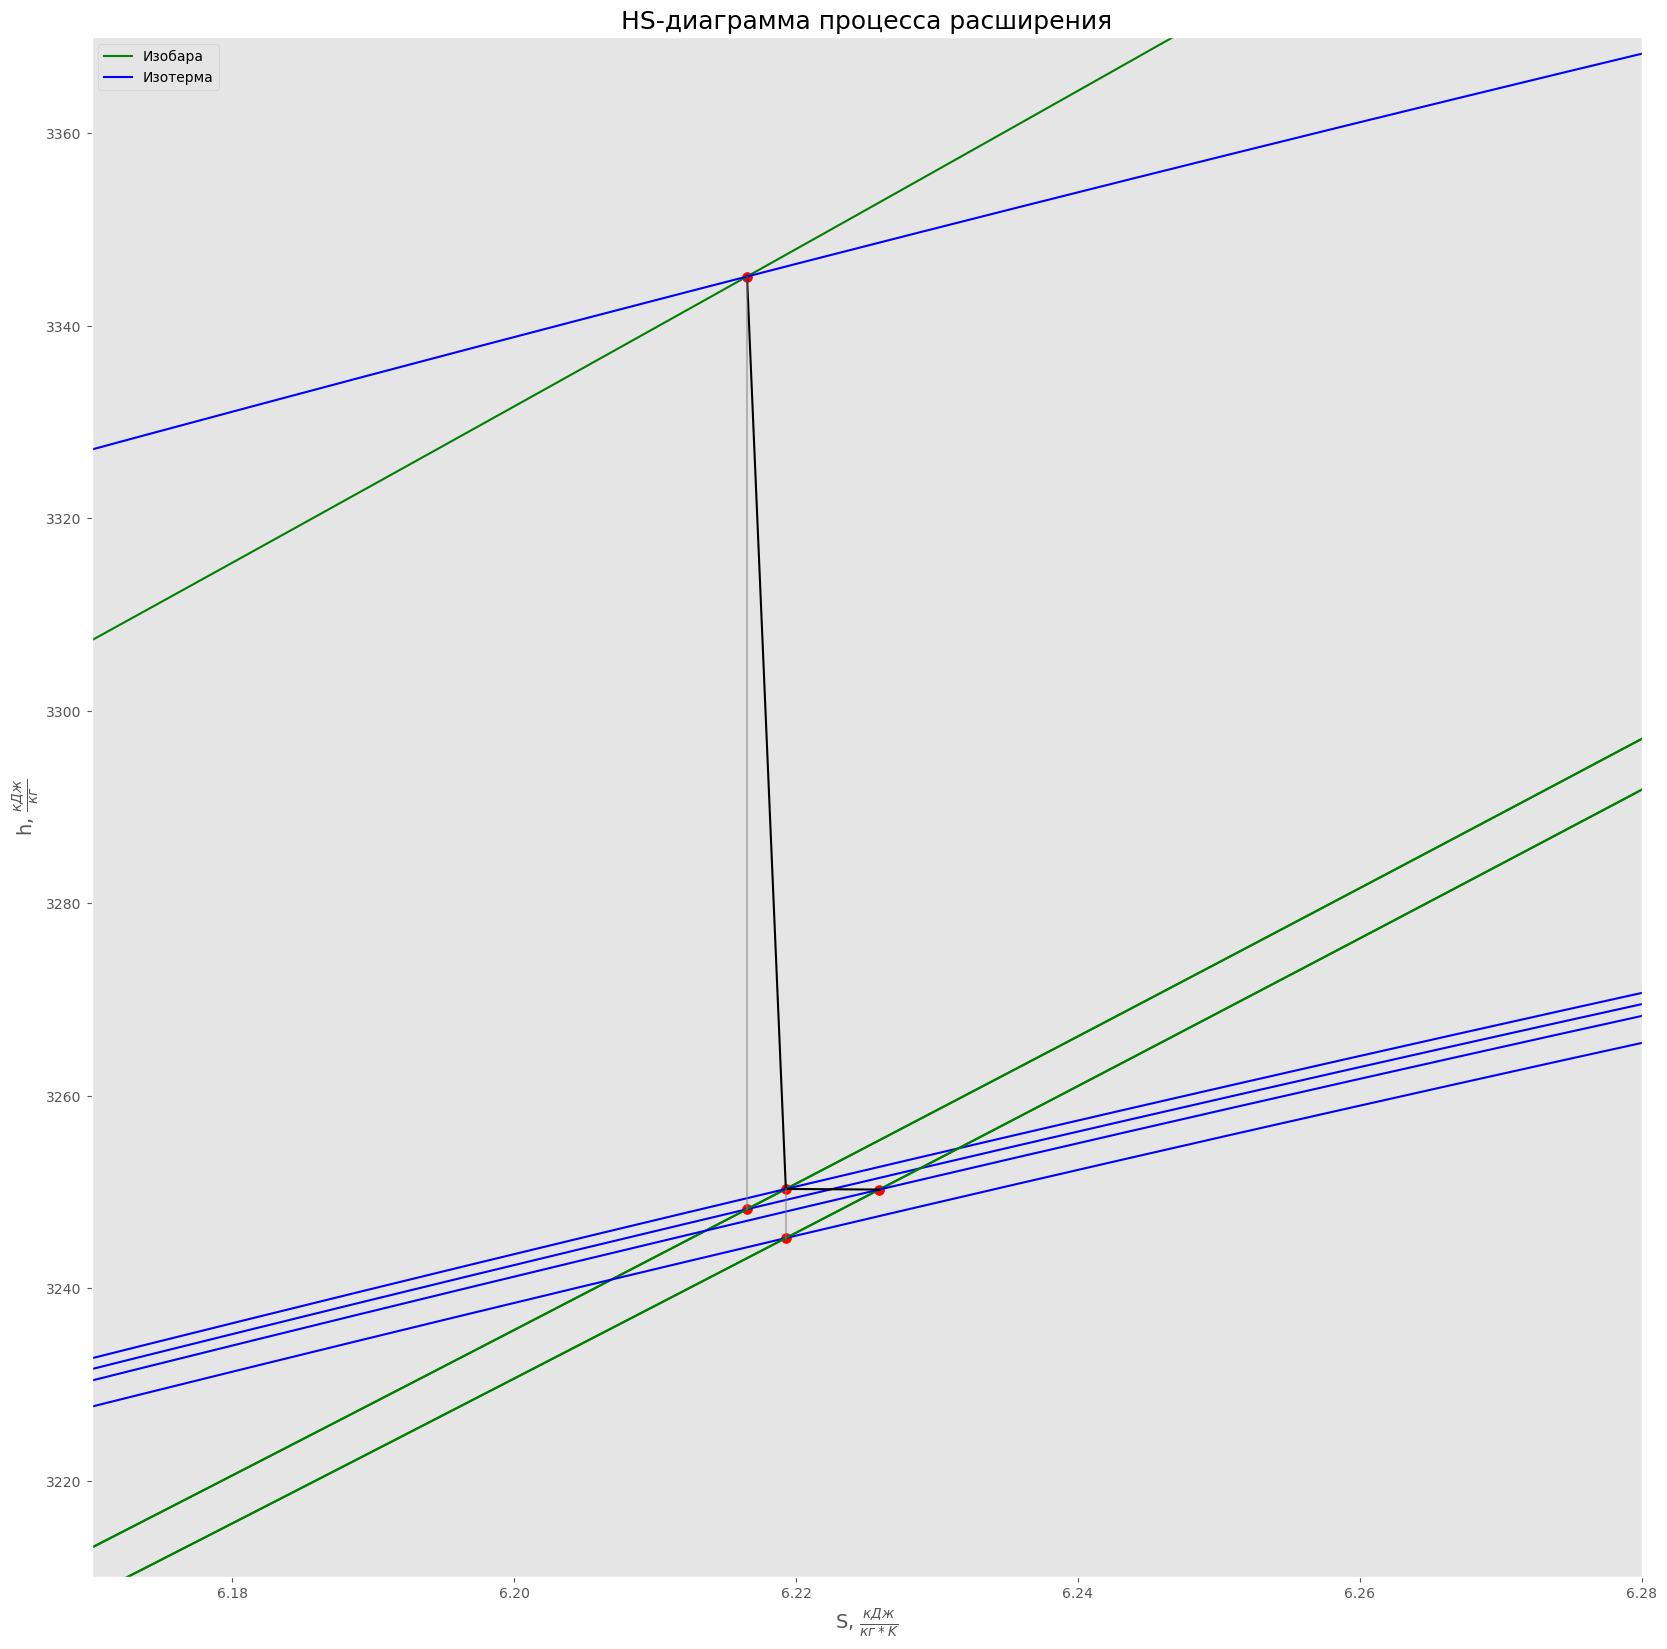

In [331]:
def setup_hs_diagram():
    """Инициализирует график HS-диаграммы"""
    fig, ax = gr.plt.subplots(1, 1, figsize=(20, 20))
    ax.set_xlim(6.17, 6.28)
    ax.set_ylim(3210, 3370)
    return fig, ax

def plot_hs_points(ax, points):
    """Отображает точки на HS-диаграмме"""
    gr.plot_hs_diagram(ax, points=points)

def plot_process_lines(ax, points_real, points_theoretical):
    """Рисует линии процессов"""
    # Реальные процессы
    gr.plot_process(ax, points=points_real[0], color='black')
    gr.plot_process(ax, points=points_real[1], color='black')
    
    # Теоретические процессы
    gr.plot_process(ax, points=points_theoretical[0], alpha=0.5, color='grey')
    gr.plot_process(ax, points=points_theoretical[1], alpha=0.5, color='grey')

def create_hs_plot(turbine, tochka_1_t, tochka_1, tochka_2_t, tochka_2):
    """Создает полную HS-диаграмму"""
    fig, ax = setup_hs_diagram()
    
    # Все точки процесса
    all_points = [turbine.point_o, tochka_1_t, tochka_1, tochka_2_t, tochka_2]
    
    # Линии процессов
    real_processes = [
        [turbine.point_o, tochka_1],
        [tochka_1, tochka_2]
    ]
    theoretical_processes = [
        [turbine.point_o, tochka_1_t],
        [tochka_1, tochka_2_t]
    ]
    
    plot_hs_points(ax, all_points)
    plot_process_lines(ax, real_processes, theoretical_processes)
    
    return table_points  
    

result = create_hs_plot(turbine, tochka_1_t, tochka_1, tochka_2_t, tochka_2)
table_points


# Треугольник скоростей

,"Абсолютная скорость (с), м/с","Абсолютный угол (α) , °","Относительная скорость выхода (w) , м/с","Относительный угол (β) , °"
,,,,
За сопловой решеткой,435.430,16.681,281.447,26.364
За рабочей решеткой,172.799,67.000,281.657,34.385


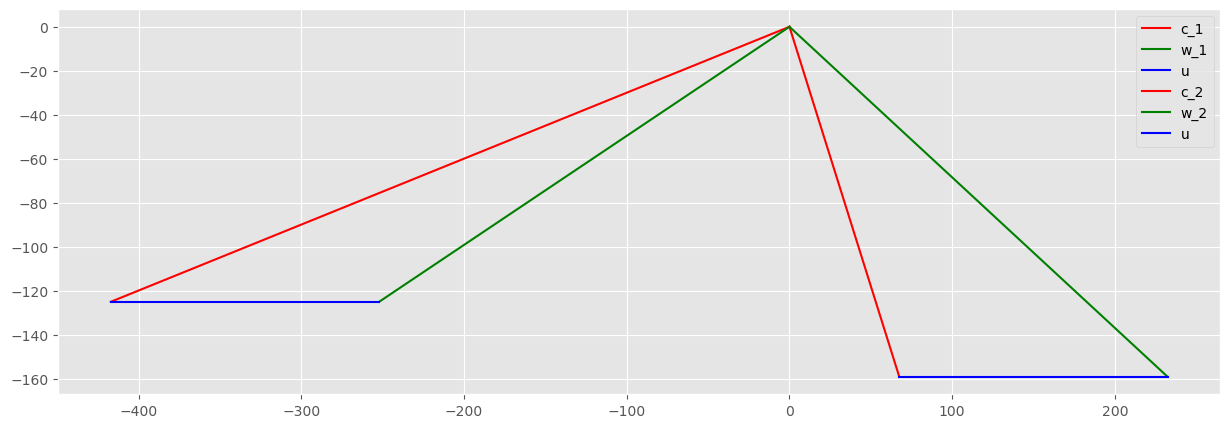

In [333]:
lop.triangle()
table_v_d

# Задание 3: Определение числа ступеней и распределение параметров по ним.

In [335]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import ssteps as steps

In [336]:
# Параметры точки 0
print(f"P_o= {tochka_0.find_p()}, МПа")  
print(f"h_o= {tochka_0.find_h()}, кДж/кг")  

P_o= 16.712726752529548, МПа
h_o= 3268.0762015382766, кДж/кг


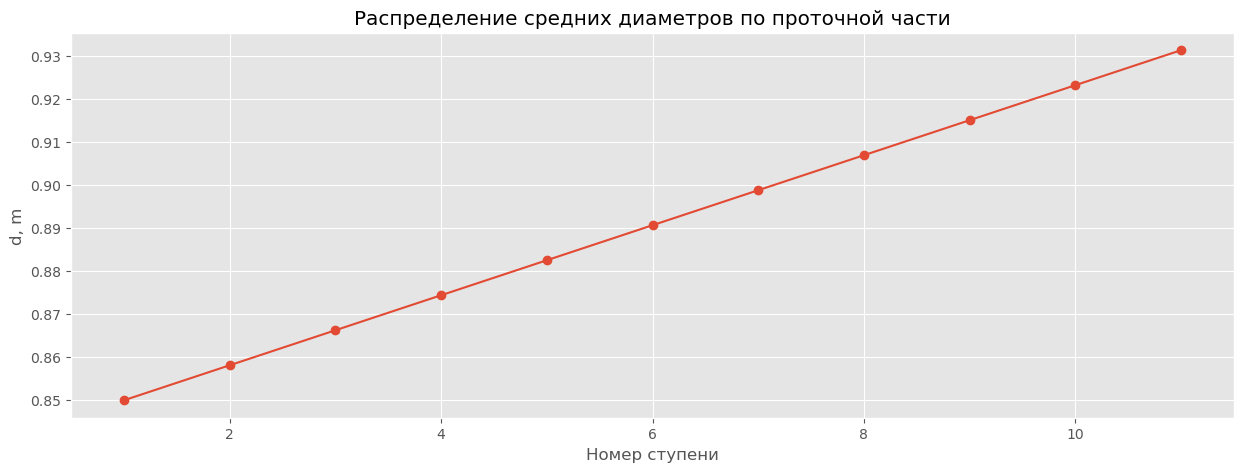

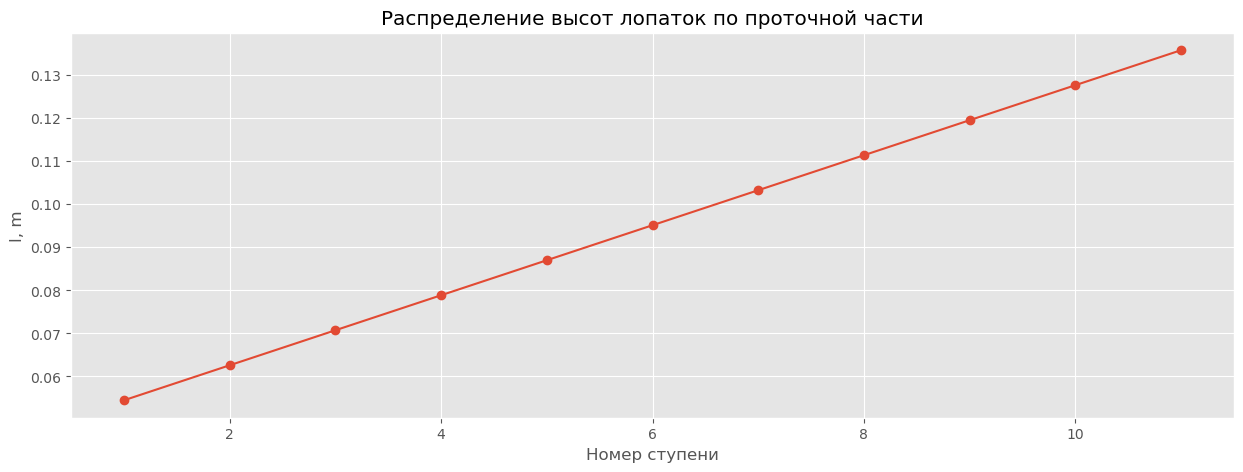

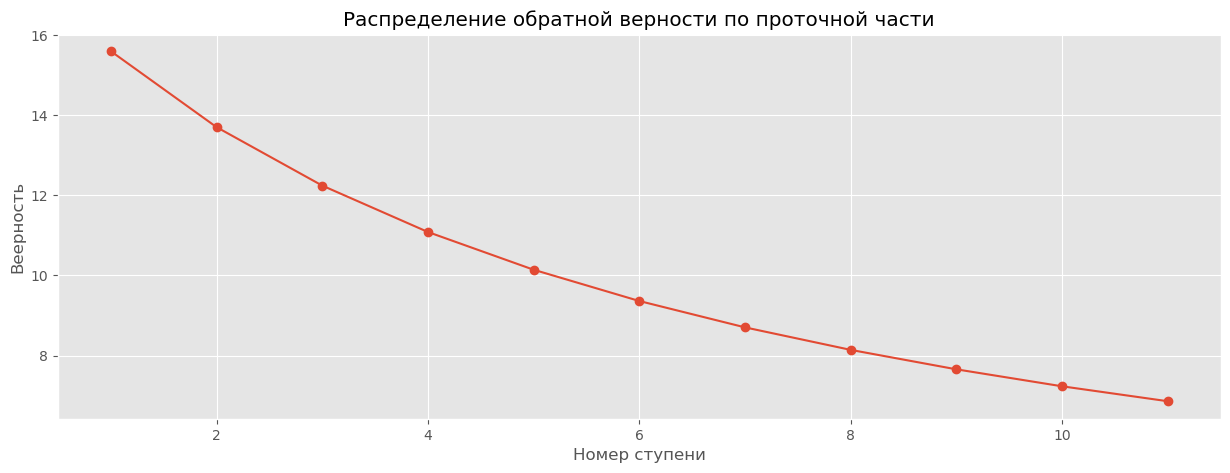

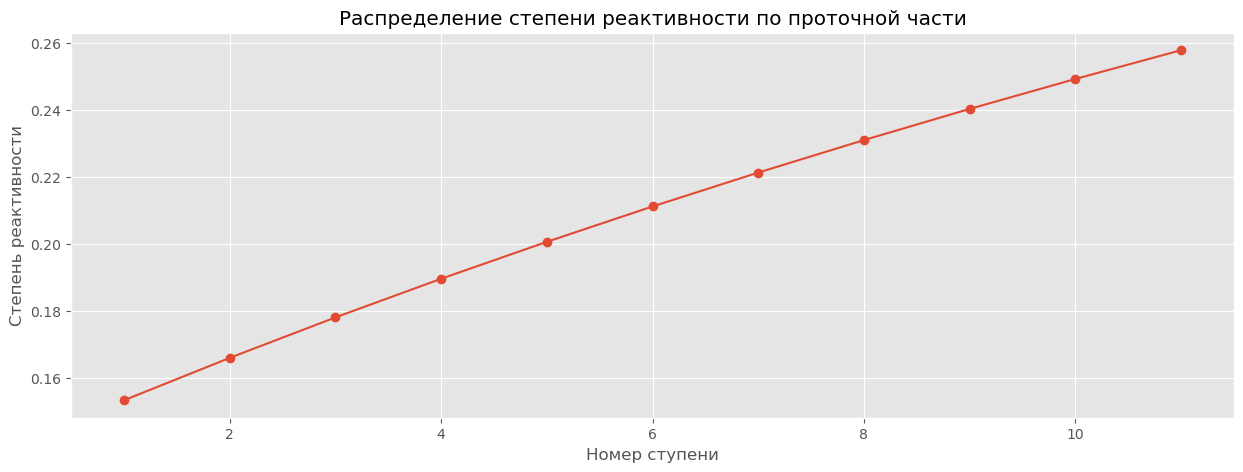

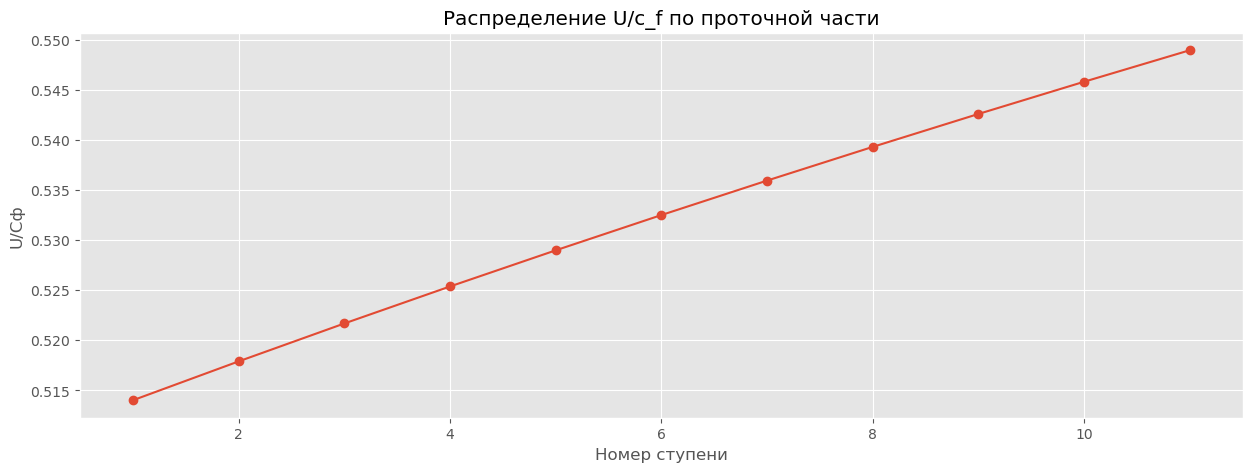

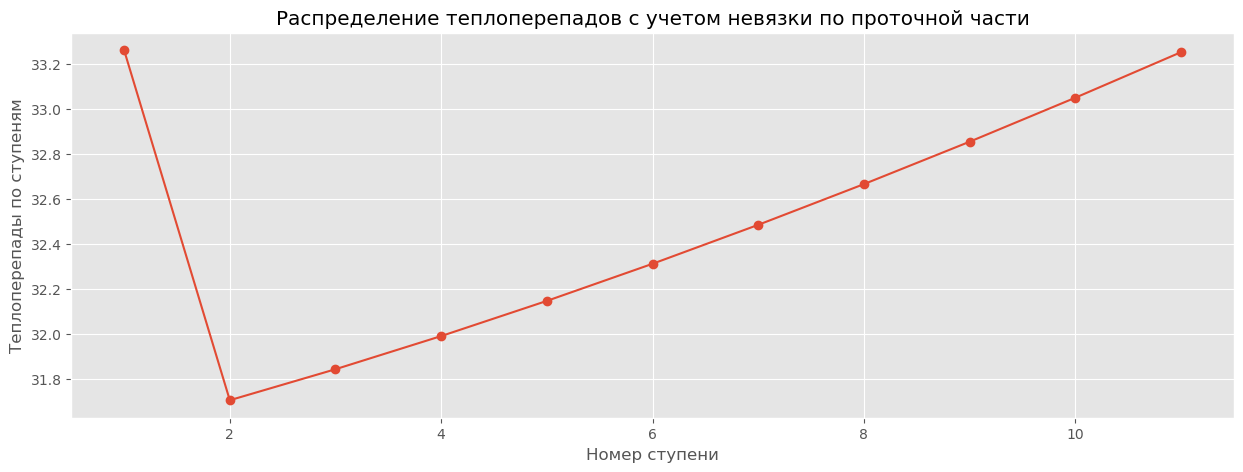

In [337]:
splitting = steps.SBS(
    d=lop.d, 
    n=lop.n, 
    n_stages=11, 
    G_0=g0, 
    P_o= 16.712726752529548,  
    h_o= 3268.0762015382766, 
    P_z=turbine.point_1_teor.find_p(), 
    fi=fi,
    alpha_1=lop.alpha_1_e, 
    ro=lop.ro, 
    mu=mu, 
    efficiency=0.85, 
    veernost_1=16.51
)

# расчеты
new_actual_heat_drop, daf = splitting.calc()

table_ver, tabl_step = splitting.table()

# графики
splitting.plot_charts()

In [338]:
table_ver

,Веерность
,
"Величина обратной веерности, задаваемая студентом",16.51
Величина расчитанной обратной веерности,16.51


In [339]:
tabl_step

,Число ступеней
,
"Величина числа ступеней, задаваемая студентом",11.0
Величина расчитанного числа ступеней,11.0


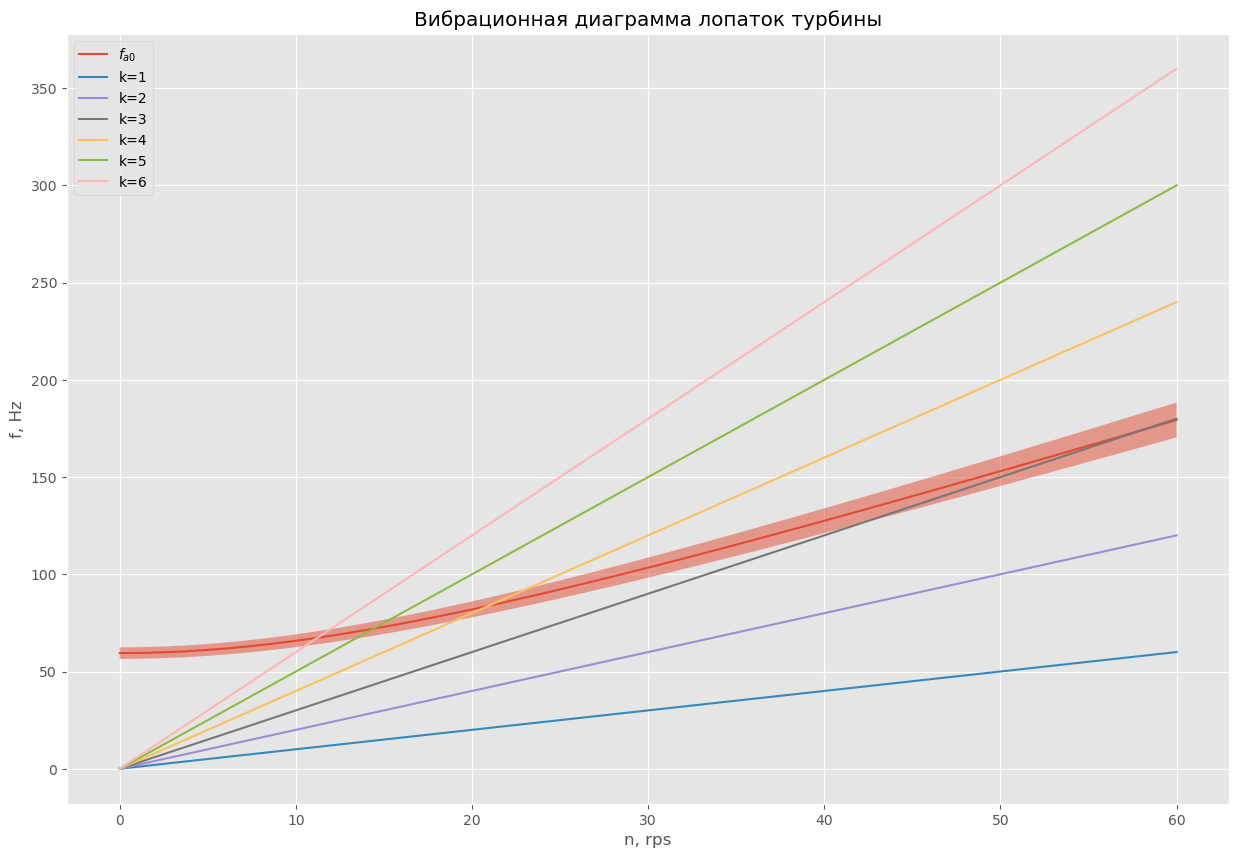

In [340]:
mm = 1/ 1000
m = 12
t = 25 * mm
beta = 85
density = 7900
E = 2 * (10**11)
z = 10
d = 1.05
l = 0.102
f = 0.04498756181811621
J = 0.36 * (10 ** (-8)) 

delta = 5 * mm
Bс = 40 * mm
psi = 0.97
tr = lop.vibration_diagram(m, t, beta, density, E,z,d, l,f,J,delta,Bс, psi)

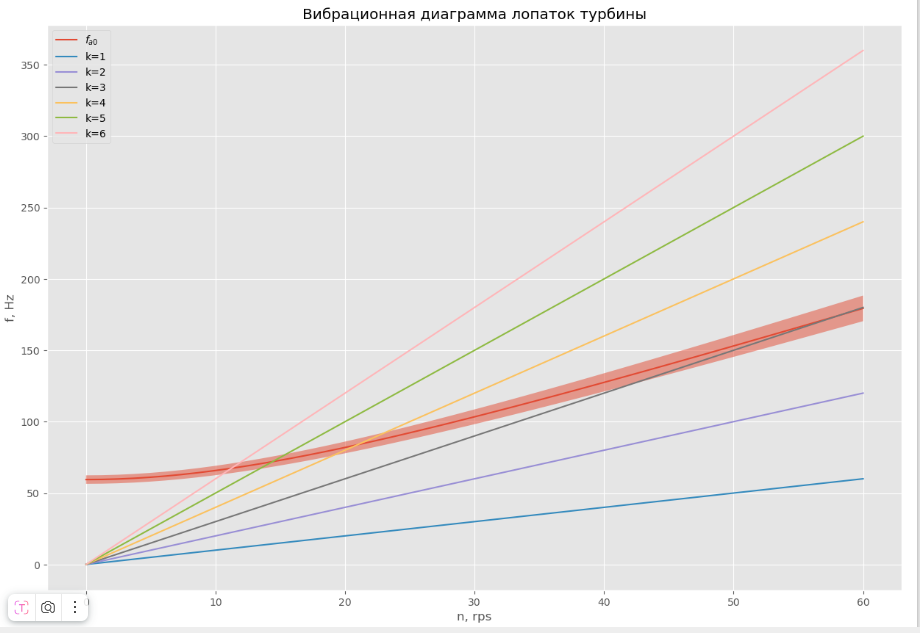

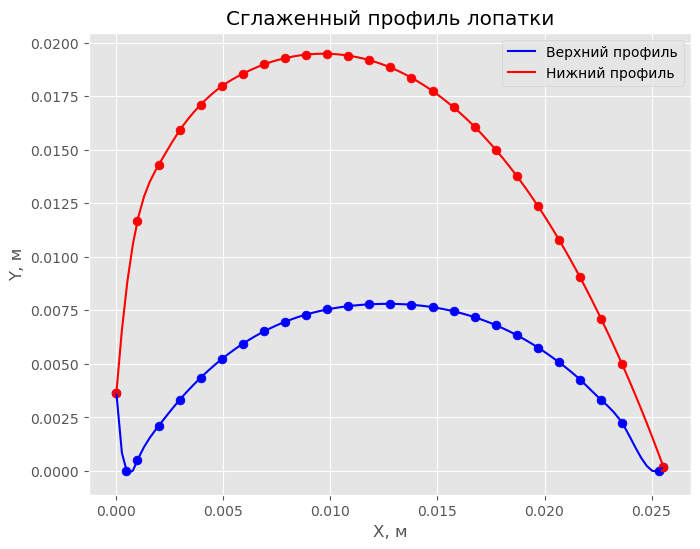

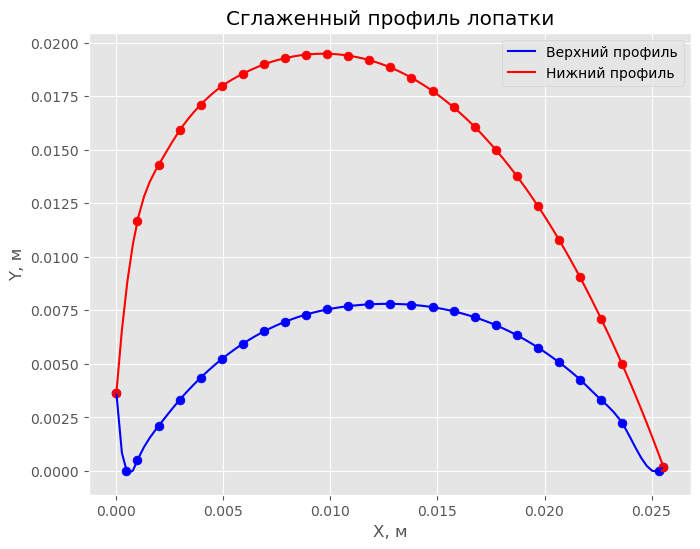

In [341]:

norm_coeff = (25.95/1000)/0.026354
xu = np.array([0,0.45,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.750,25.95])/1000*norm_coeff
xl = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.95])/1000*norm_coeff
yu = np.array([3.7,0,0.5,2.130,3.368,4.422,5.305,6.032,6.617,7.074,7.417,7.659,7.816,7.902,7.925,7.883,7.767,7.572,7.29,6.915,6.438,5.853,5.153,4.328,3.366,2.259,0,0.2])/1000*norm_coeff
yl = np.array([3.7,11.862,14.5,16.150,17.375,18.25,18.842,19.285,19.581,19.75,19.791,19.704,19.488,19.139,18.652,18.023,17.247,16.32,15.235,13.986,12.565,10.966,9.182,7.209,5.049,0.2])/1000*norm_coeff

# Вызов новой функции
plot_smoothed_profile_fixed(lop, xu, yu, xl, yl)

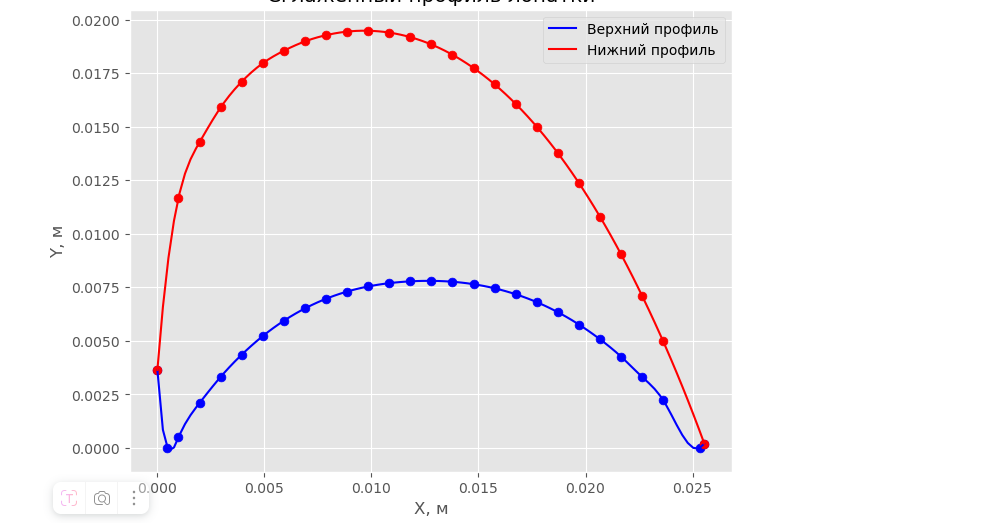

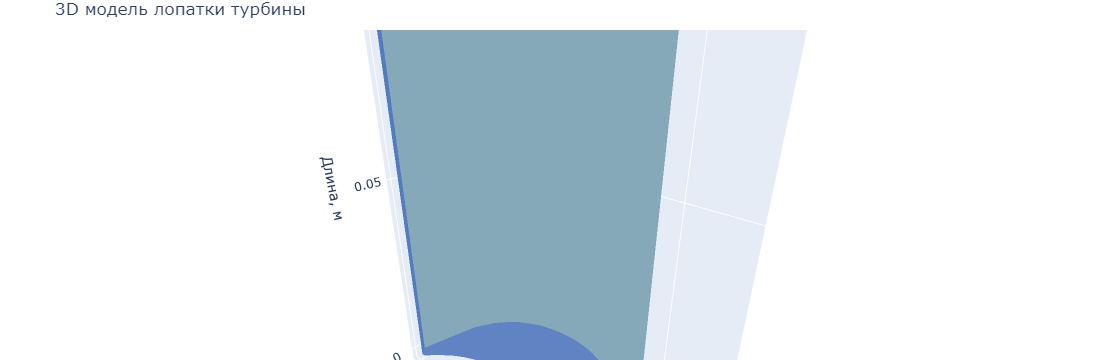

In [342]:
import numpy as np
from scipy.interpolate import interp1d
import plotly.graph_objects as go

def create_3d_blade(xu, yu, xl, yl, length, num_slices=50, scale=1.0):

    # Интерполяция профиля
    f_u = interp1d(xu, yu, kind='cubic')
    f_l = interp1d(xl, yl, kind='cubic')
    

    xu_scaled = xu * scale
    xl_scaled = xl * scale
    

    z_coords = np.linspace(0, length, num_slices)
    x_u = np.tile(xu_scaled, (num_slices, 1))
    z_u = np.tile(z_coords.reshape(-1, 1), (1, len(xu_scaled)))
    y_u = np.array([f_u(x) for x in xu])  # Y не масштабируем
    y_u = np.tile(y_u, (num_slices, 1))
    
    x_l = np.tile(xl_scaled, (num_slices, 1))
    z_l = np.tile(z_coords.reshape(-1, 1), (1, len(xl_scaled)))
    y_l = np.array([f_l(x) for x in xl])  # Y не масштабируем
    y_l = np.tile(y_l, (num_slices, 1))
    
    return (x_u, y_u, z_u), (x_l, y_l, z_l)

def plot_3d_model(upper, lower):
    """Интерактивная 3D визуализация без напряжений"""
    x_u, y_u, z_u = upper
    x_l, y_l, z_l = lower
    
    fig = go.Figure()
    
  
    fig.add_trace(go.Surface(
        x=x_u, y=y_u, z=z_u,
        colorscale=[[0, 'rgb(100,149,237)'], [1, 'rgb(100,149,237)']],
        showscale=False,
        opacity=0.9
    ))
    
 
    fig.add_trace(go.Surface(
        x=x_l, y=y_l, z=z_l,
        colorscale=[[0, 'rgb(173,216,230)'], [1, 'rgb(173,216,230)']],
        showscale=False,
        opacity=0.9
    ))
    

    fig.update_layout(
        title='3D модель лопатки турбины',
        scene=dict(
            xaxis_title='Ширина, м',
            yaxis_title='Высота, м',
            zaxis_title='Длина, м',
            aspectmode='manual',
            aspectratio=dict(x=2, y=1, z=3),  # Подберите эти значения!
            camera=dict(
                eye=dict(x=1.5, y=-1.5, z=0.8),
                up=dict(x=0, y=0, z=1)
            )
        ),
        margin=dict(l=0, r=0, b=0, t=30)
    )
    
    fig.show()

diameter = 1.05  # м
blade_length = 0.102  # м
norm_coeff = (25.72/1000)/0.026354

xu = np.array([0,0.68,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.21,25.41])/1000*norm_coeff
yu = np.array([0.68,0,0.08,1.245,2.21,2.973,3.572,4.046,4.431,4.763,5.046,5.277,5.449,5.56,5.602,5.573,5.473,5.305,5.074,4.784,4.439,4.028,3.532,2.928,2.196,1.4,0,0.2])/1000*norm_coeff
xl = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.41])/1000*norm_coeff
yl = np.array([0.68,6.687,8.912,10.312,11.312,12,12.649,13.036,13.345,13.568,13.701,13.737,13.67,13.493,13.2,12.785,12.241,11.562,10.744,9.788,8.693,7.457,6.08,4.562,2.885,0.2])/1000*norm_coeff


scale_factor = 3.0  
upper, lower = create_3d_blade(xu, yu, xl, yl, blade_length, scale=scale_factor)


plot_3d_model(upper, lower)

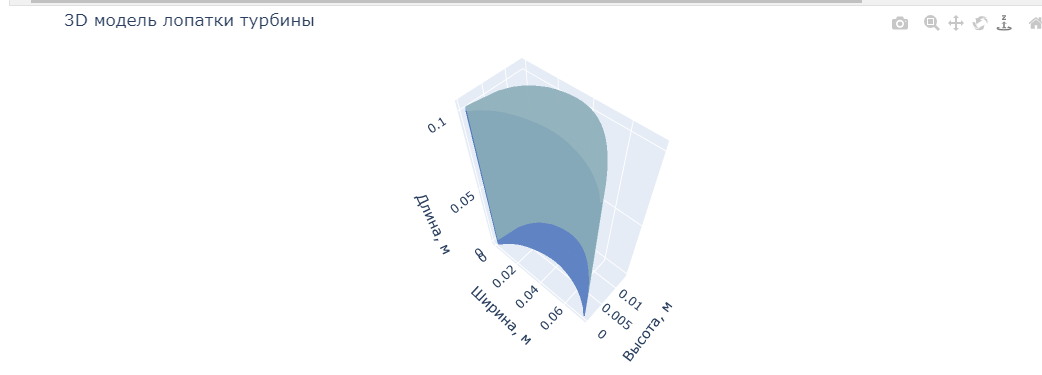

In [343]:

upper_3d = np.column_stack((
    xu, 
    yu, 
    np.full(len(xu), 0.1) 
))


lower_3d = np.column_stack((
    xl, 
    yl, 
    np.full(len(xl), 0.1)  
))


combined_3d = np.vstack((upper_3d, lower_3d))

In [344]:
l = lop.l_2 
avg_d = lop.d
density = 7800
z = 274
n = 50
W = 0.19 * 1e-6
MPa = 10e6

max_stress = 400 * MPa
max_allowed_stress = 235 * MPa

tension_stress_root_func = lambda x: 0.5 * density * (x ** 2) * avg_d * l


angular_speed = 2 * np.pi * n
assert tension_stress_root_func(angular_speed) < max_allowed_stress
print(f"Запас прочности: {max_stress / tension_stress_root_func(angular_speed)}")
increased_angular_speed = 1.1 * angular_speed
assert tension_stress_root_func(increased_angular_speed) < max_allowed_stress
tension_stress_root_func(increased_angular_speed) / MPa
print(f"Запас прочности: {max_stress / tension_stress_root_func(increased_angular_speed)}")

def tension_stress(x):
    r_root = (avg_d - l) / 2
    constant_part = density * (angular_speed ** 2)
    left = r_root * (l - x)
    right = 0.5 * ((l ** 2) - (x ** 2))
    return constant_part * (left + right)

y = np.linspace(0, l, 100)

Запас прочности: 369.81362803124324
Запас прочности: 305.63109754648195


In [345]:
import numpy as np
import matplotlib.pyplot as plt

from functools import partial
from typing import Callable, List, Tuple, Union, Optional

from scipy.integrate import dblquad, quad


def __patch_variable(value: Union[Callable, int, float]) -> Callable:
    """
    Patch variable which should be Callable. Usually it is variable depending on cross-section
    :param Union[Callable, int, float] value:
    :return Callable:
    """
    if callable(value):
        return value
    else:
        return lambda x: value
    
def __patch_multiple(*args) -> List[Callable]:
    """
    Patch multiple variables at time
    :param args: None keyword args
    :return List[Callable]:
    """
    return [__patch_variable(variable) for variable in args]


def _distribution_loading_x(
    z: Union[int, float],
    density: Callable,
    outlet_axial_speed: Callable,
    inlet_tangential_speed: Callable,
    outlet_tangential_speed: Callable,
    pitch: Callable,
) -> float:
    """
    Distribution loading in cross-section of blade profile for blade bending
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Callable density: Density after blade row, kg / m ** 3
    :param Callable outlet_axial_speed: Axial speed behind blade row, m / s
    :param Callable inlet_tangential_speed: Inlet tangential speed, m / s
    :param Callable outlet_tangential_speed: Outlet tangential speed, m / s
    :param Callable pitch: Blade to blade distance at cross-section z
    :return float:
    """
    rho = density(z)
    step = pitch(z)
    outlet_axial_speed_projection = outlet_axial_speed(z)
    inlet_tangential_projection = inlet_tangential_speed(z)
    outlet_tangential_projection = outlet_tangential_speed(z)
    return rho * step * outlet_axial_speed_projection * (inlet_tangential_projection + outlet_tangential_projection)


def _distribution_loading_y(
    z: Union[int, float],
    density: Callable,
    inlet_axial_speed: Callable,
    outlet_axial_speed: Callable,
    inlet_pressure_profile: Callable,
    outlet_pressure_profile: Callable,
    pitch: Callable,
) -> float:
    """
    Distribution loading in cross-section of blade profile for blade bending
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Callable density: Density after blade row, kg / m ** 3
    :param Callable inlet_axial_speed: Axial speed in front of blade row, m / s
    :param Callable outlet_axial_speed: Axial speed behind blade row, m / s
    :param Callable inlet_pressure_profile: Pressure before blade row, Pa
    :param Callable outlet_pressure_profile: Pressure after blade row, Pa
    :param Callable pitch: Blade to blade distance at cross-section z
    :return float:
    """
    rho = density(z)
    step = pitch(z)
    inlet_axial_projection = inlet_axial_speed(z)
    outlet_axial_projection = outlet_axial_speed(z)
    p_in = inlet_pressure_profile(z)
    p_out = outlet_pressure_profile(z)

    speed_part = rho * step * outlet_axial_projection * (inlet_axial_projection - outlet_axial_projection)
    pressure_part = step * (p_in - p_out)

    return speed_part + pressure_part


def _bending_moment_from_distributed_force(
    z: Union[int, float],
    loading: Callable,
    blade_length: Union[int, float],
) -> float:
    """
    Bending loading in cross-section of blade profile for blade bending
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Callable loading: Loading function f(x), probably should be partial
    :param Union[int, float] blade_length: Blade length, m. Upper bound for integral
    :return float:
    """

    def to_integrate(variable):
        return loading(variable) * (variable - z)

    moment = quad(to_integrate, z, blade_length)[0]
    return moment


def _bending_moment_projections(
    z: Union[int, float],
    blade_length: Union[int, float],
    density: Callable,
    inlet_axial_speed: Callable,
    outlet_axial_speed: Callable,
    inlet_tangential_speed: Callable,
    outlet_tangential_speed: Callable,
    inlet_pressure_profile: Callable,
    outlet_pressure_profile: Callable,
    pitch: Callable,
    angle_of_frame: Callable,
    is_rotor: bool = True,
) -> Tuple[float, float]:
    """
    Define min and max bending moments related to axis with min and max inertia moments
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Union[int, float] blade_length: Blade length, m. Upper bound for integral
    :param Callable density: Density after blade row, kg / m ** 3
    :param Callable inlet_axial_speed: Axial speed in front of blade row, m / s
    :param Callable outlet_axial_speed: Axial speed behind blade row, m / s
    :param Callable inlet_tangential_speed: Inlet tangential speed, m / s
    :param Callable outlet_tangential_speed: Outlet tangential speed, m / s
    :param Callable inlet_pressure_profile: Pressure before blade row, Pa
    :param Callable outlet_pressure_profile: Pressure after blade row, Pa
    :param Callable pitch: Blade to blade distance at cross-section z
    :param Callable angle_of_frame: Blade profile angle of frame for min-max inertia moments
    :param bool is_rotor: Binary flag to specify type of blade
    :return Tuple[float, float]: moment eta, moment zeta
    """

    angle_of_frame = __patch_variable(angle_of_frame)
    cos_beta = np.cos(np.deg2rad(angle_of_frame(z)))
    sin_beta = np.sin(np.deg2rad(angle_of_frame(z)))

    loading_x = partial(
        _distribution_loading_y,
        density=density,
        inlet_axial_speed=inlet_axial_speed,
        outlet_axial_speed=outlet_axial_speed,
        inlet_pressure_profile=inlet_pressure_profile,
        outlet_pressure_profile=outlet_pressure_profile,
        pitch=pitch,
    )

    loading_y = partial(
        _distribution_loading_x,
        density=density,
        outlet_axial_speed=outlet_axial_speed,
        inlet_tangential_speed=inlet_tangential_speed,
        outlet_tangential_speed=outlet_tangential_speed,
        pitch=pitch,
    )

    moment_x = _bending_moment_from_distributed_force(
        z=z,
        blade_length=blade_length,
        loading=loading_x,
    )
    moment_y = _bending_moment_from_distributed_force(
        z=z,
        blade_length=blade_length,
        loading=loading_y,
    )

    moment_eta = moment_y * cos_beta + moment_x * sin_beta
    moment_zeta = moment_y * sin_beta - moment_x * cos_beta

    return moment_eta, moment_zeta


def blade_bending_stress(
    z: Union[int, float],
    blade_length: Union[int, float],
    density: Union[Callable, float],
    inlet_axial_speed: Union[Callable, float],
    outlet_axial_speed: Union[Callable, float],
    inlet_tangential_speed: Union[Callable, float],
    outlet_tangential_speed: Union[Callable, float],
    inlet_pressure_profile: Union[Callable, float],
    outlet_pressure_profile: Union[Callable, float],
    pitch: Union[Callable, float],
    angle_of_frame: Union[Callable, float],
    eta_moment_inertia: Union[Callable, float],
    zeta_moment_inertia: Union[Callable, float],
    coordinates: Union[Tuple[float, float], np.ndarray],
    is_rotor: bool = True,
) -> Union[np.ndarray, float]:
    """
    Define stress from bending moment at specific cross-section Z and coordinates of profile
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Union[int, float] blade_length: Blade length, m. Upper bound for integral
    :param Union[Callable, float] density: Density after blade row, kg / m ** 3
    :param Union[Callable, float] inlet_axial_speed: Axial speed in front of blade row, m / s
    :param Union[Callable, float] outlet_axial_speed: Axial speed behind blade row, m / s
    :param Union[Callable, float] inlet_tangential_speed: Inlet tangential speed, m / s
    :param Union[Callable, float] outlet_tangential_speed: Outlet tangential speed, m / s
    :param Union[Callable, float] inlet_pressure_profile: Pressure before blade row, Pa
    :param Union[Callable, float] outlet_pressure_profile: Pressure after blade row, Pa
    :param Union[Callable, float] pitch: Blade to blade distance at cross-section z
    :param Union[Callable, float] angle_of_frame: Blade profile angle of frame for min-max inertia moments
    :param Union[Callable, float] zeta_moment_inertia: Max moment of inertia, m ** 4
    :param Union[Callable, float] eta_moment_inertia: Min moment of inertia, m ** 4
    :param Union[Tuple[float, float], np.ndarray] coordinates: Coordinates of profile to compute stress at this point.
        First coordinate related axis with min moment if inertia, second with max one. (eta_coordinate, zeta_coordinate)
    :param bool is_rotor: Binary flag to specify type of blade
    :return Union[float, np.ndarray]:
    """

    (
        density,
        inlet_axial_speed,
        outlet_axial_speed,
        inlet_tangential_speed,
        outlet_tangential_speed,
        inlet_pressure_profile,
        outlet_pressure_profile,
        pitch,
        zeta_moment_inertia,
        eta_moment_inertia,
        angle_of_frame,
    ) = __patch_multiple(
        density,
        inlet_axial_speed,
        outlet_axial_speed,
        inlet_tangential_speed,
        outlet_tangential_speed,
        inlet_pressure_profile,
        outlet_pressure_profile,
        pitch,
        zeta_moment_inertia,
        eta_moment_inertia,
        angle_of_frame,
    )

    moment_eta, moment_zeta = _bending_moment_projections(
        z=z,
        blade_length=blade_length,
        density=density,
        inlet_axial_speed=inlet_axial_speed,
        outlet_axial_speed=outlet_axial_speed,
        inlet_tangential_speed=inlet_tangential_speed,
        outlet_tangential_speed=outlet_tangential_speed,
        inlet_pressure_profile=inlet_pressure_profile,
        outlet_pressure_profile=outlet_pressure_profile,
        pitch=pitch,
        angle_of_frame=angle_of_frame,
        is_rotor=is_rotor,
    )
    if isinstance(coordinates, np.ndarray):
        if coordinates.ndim == 2:
            stress = (-moment_eta * coordinates[:, 1] / eta_moment_inertia(z)) + (
                moment_zeta * coordinates[:, 0] / zeta_moment_inertia(z)
            )
            return stress

    stress = (-moment_eta * coordinates[1] / eta_moment_inertia(z)) + (
        moment_zeta * coordinates[0] / zeta_moment_inertia(z)
    )

    return stress
def rotate(x: np.ndarray, angle: float) -> np.ndarray:
    """
    Rotate x around [0, 0] on `angle` degree
    :param np.ndarray x: [[x1, x2, x3,...], [y1, y2, y3, ...]]
    :param float angle: Angle in degree to rotate
    :return np.ndarray:
    """
    _angle = np.deg2rad(angle)
    rotation_matrix = np.array([[np.cos(_angle), -np.sin(_angle)], [np.sin(_angle), np.cos(_angle)]])

    return x.dot(rotation_matrix)

def bending_stress_coordinates(full_points, angle_of_frame, diameter) -> np.ndarray:
    """
    Full coordinates of profile to compute bending blade stress
    :return np.ndarray: np.ndarray([eta, zeta. Z])
    """
    coordinates = rotate(full_points[:, [0, 1]], 90 + angle_of_frame)
    coordinates[:, [0, 1]] = coordinates[:, [1, 0]]
    diameter = np.ones_like(coordinates[:, 0])[:, None] * diameter
    coordinates = np.hstack((coordinates, diameter))
    return coordinates

full_points = combined_3d
coordinates = bending_stress_coordinates(full_points=combined_3d, angle_of_frame=33.2, diameter=lop.d)
coordinates.shape

(54, 3)

In [346]:

P_in = 22.4  * 1e6
P_out = 3.1 * 1e6


inlet_axial_speed = 93
outlet_axial_speed = 435.305
inlet_tangential_speed = 239.045
outlet_tangential_speed = 241
eta_moment_inertia = i_minimum = 0.575
zeta_moment_inertia = i_maximum = 1.74
angle_of_frame = 75.8
angle_of_frame = angle_of_frame + 90
density = 7900
blade_length = lop.l_2

bending_stress = blade_bending_stress(
    z=0.05,
    blade_length=blade_length,
    density=density,
    inlet_axial_speed=inlet_axial_speed,
    outlet_axial_speed=outlet_axial_speed,
    inlet_tangential_speed=inlet_tangential_speed,
    outlet_tangential_speed=outlet_tangential_speed,
    inlet_pressure_profile=P_in,
    outlet_pressure_profile=P_out,
    pitch=0.65,
    angle_of_frame=angle_of_frame,
    eta_moment_inertia=eta_moment_inertia,
    zeta_moment_inertia=zeta_moment_inertia,
    coordinates=coordinates,
) / 1e6


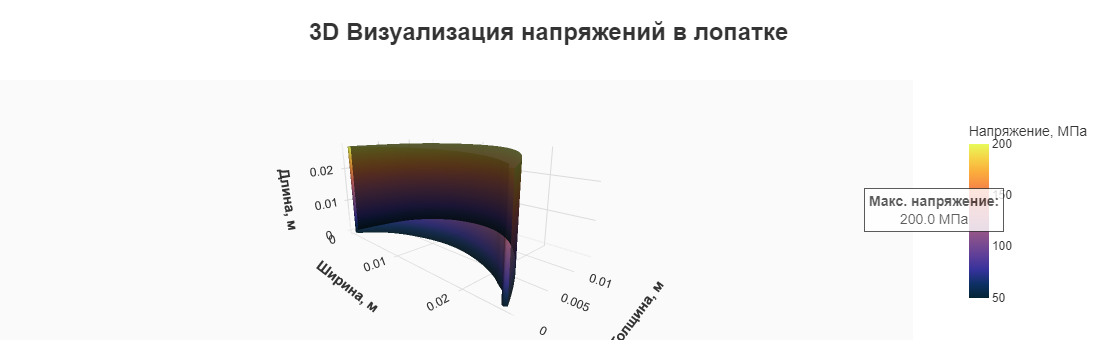

In [347]:
import numpy as np
from scipy.interpolate import interp1d
import plotly.graph_objects as go

def plot_3d_blade_with_stress(xu, yu, xl, yl, stress_distribution, 
                             height=0.1, num_points=100):
 
    f_u = interp1d(xu, yu, kind='cubic')
    x_u = np.linspace(min(xu), max(xu), num_points)
    y_u = f_u(x_u)
    
    f_l = interp1d(xl, yl, kind='cubic')
    x_l = np.linspace(min(xl), max(xl), num_points)
    y_l = f_l(x_l)

  
    z_coords = np.linspace(0, height, num_points)
    
 
    stress_interp = interp1d(np.linspace(0, height, len(stress_distribution)),
                            stress_distribution,
                            kind='linear',
                            fill_value='extrapolate')
    

    X_u, Z_u = np.meshgrid(x_u, z_coords)
    Y_u = np.array([y_u]*num_points)
    
    X_l, Z_l = np.meshgrid(x_l, z_coords)
    Y_l = np.array([y_l]*num_points)
    

    stress = stress_interp(z_coords)[:, np.newaxis]


    fig = go.Figure()
    

    fig.add_trace(go.Surface(
        x=X_u,
        y=Y_u,
        z=Z_u,
        surfacecolor=np.repeat(stress, len(x_u), axis=1),
        colorscale='thermal',
        opacity=0.95,
        showscale=True,
        name='Напряжения',
        colorbar=dict(
            title='Напряжение, МПа',
            thickness=20,
            len=0.75,
            x=1.05
        ),
        lighting=dict(
            ambient=0.4,
            diffuse=0.8,
            fresnel=0.1,
            specular=0.5,
            roughness=0.3
        ),
        lightposition=dict(x=100, y=100, z=1000)
    ))
    
    # Нижняя поверхность
    fig.add_trace(go.Surface(
        x=X_l,
        y=Y_l,
        z=Z_l,
        surfacecolor=np.repeat(stress, len(x_l), axis=1),
        colorscale='thermal',
        showscale=False,
        opacity=0.9,
        lighting=dict(
            ambient=0.3,
            diffuse=0.7,
            fresnel=0.1,
            specular=0.4,
            roughness=0.4
        )
    ))
    

    edge_colors = ['rgb(255,255,255)', 'rgb(200,200,200)']  # Белый и серый для кромок
    for i, edge_idx in enumerate([0, -1]):
        fig.add_trace(go.Surface(
            x=np.array([[xu[edge_idx], xl[edge_idx]]]*num_points),
            y=np.array([[yu[edge_idx], yl[edge_idx]]]*num_points),
            z=np.array([z_coords, z_coords]).T,
            surfacecolor=stress,
            colorscale=[[0, edge_colors[i]], [1, edge_colors[i]]],
            showscale=False,
            opacity=1.0,
            lighting=dict(
                ambient=0.6,
                diffuse=0.9,
                specular=0.5
            )
        ))
    

    fig.update_layout(
        title=dict(
            text='<b>3D Визуализация напряжений в лопатке</b>',
            font=dict(size=24, family="Arial", color="#333333"),
            x=0.5,
            xanchor='center'
        ),
        scene=dict(
            xaxis_title='<b>Ширина, м</b>',
            yaxis_title='<b>Толщина, м</b>',
            zaxis_title='<b>Длина, м</b>',
            aspectmode='manual',
            aspectratio=dict(x=1.8, y=1, z=0.8),
            camera=dict(
                eye=dict(x=1.7, y=-1.7, z=0.6),
                up=dict(x=0, y=0, z=1),
                center=dict(x=0, y=0, z=-0.1)
            ),
            bgcolor='rgb(250,250,250)',
            xaxis=dict(
                gridcolor='rgb(220,220,220)',
                backgroundcolor='rgb(250,250,250)'
            ),
            yaxis=dict(
                gridcolor='rgb(220,220,220)',
                backgroundcolor='rgb(250,250,250)'
            ),
            zaxis=dict(
                gridcolor='rgb(220,220,220)',
                backgroundcolor='rgb(250,250,250)'
            )
        ),
        margin=dict(l=0, r=100, b=20, t=80),
        paper_bgcolor='white',
        plot_bgcolor='white',
        font=dict(family="Arial", size=12, color="#333333")
    )
    

    fig.add_annotation(
        x=1.1,
        y=0.5,
        xref='paper',
        yref='paper',
        text="<b>Макс. напряжение:</b><br>{:.1f} МПа".format(max(stress_distribution)),
        showarrow=False,
        font=dict(size=14),
        bordercolor="#333333",
        borderwidth=1,
        borderpad=4,
        bgcolor="white",
        opacity=0.8
    )
    
    fig.show()


plot_3d_blade_with_stress(xu, yu, xl, yl, 
                         stress_distribution=stress_values,
                         height=lop.l_2,
                         num_points=100)

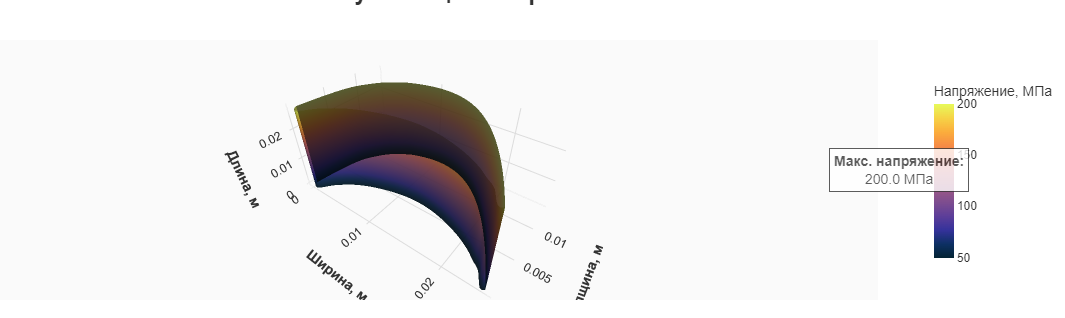

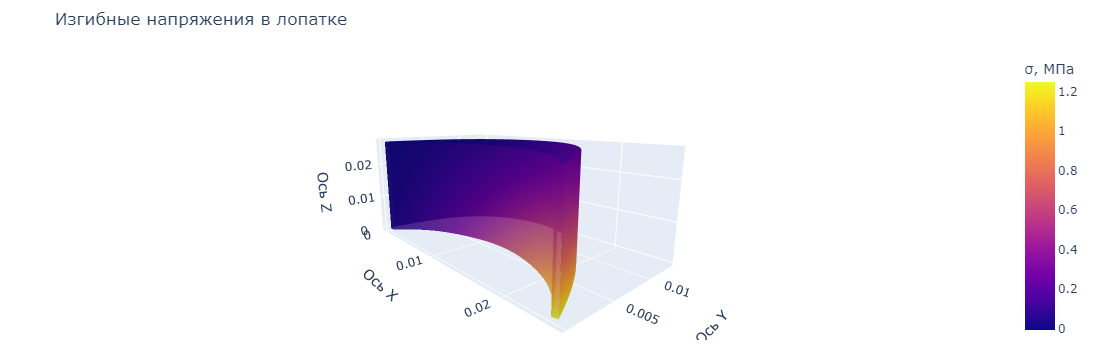

In [348]:
import numpy as np
from scipy.interpolate import interp1d
import plotly.graph_objects as go

def plot_3d_bending_stress(xu, yu, xl, yl, 
                          blade_length, density,
                          inlet_axial_speed, outlet_axial_speed,
                          inlet_tangential_speed, outlet_tangential_speed,
                          inlet_pressure_profile, outlet_pressure_profile,
                          pitch, angle_of_frame,
                          eta_moment_inertia, zeta_moment_inertia,
                          height=0.1, num_points=100):

    f_u = interp1d(xu, yu, kind='cubic')
    x_u = np.linspace(min(xu), max(xu), num_points)
    y_u = f_u(x_u)
    
    f_l = interp1d(xl, yl, kind='cubic')
    x_l = np.linspace(min(xl), max(xl), num_points)
    y_l = f_l(x_l)

    z_levels = np.linspace(0, height, num_points)
    X_u, Z_u = np.meshgrid(x_u, z_levels)
    Y_u = np.array([y_u]*num_points)
    
    X_l, Z_l = np.meshgrid(x_l, z_levels)
    Y_l = np.array([y_l]*num_points)

    stress_upper = np.zeros_like(X_u)
    stress_lower = np.zeros_like(X_l)

    for i, z in enumerate(z_levels):
        coords_upper = np.column_stack([x_u, y_u, np.full_like(x_u, z)])
        coords_lower = np.column_stack([x_l, y_l, np.full_like(x_l, z)])
        all_coords = np.vstack([coords_upper, coords_lower])
        
        stresses = blade_bending_stress(
            z=z,
            blade_length=blade_length,
            density=density,
            inlet_axial_speed=inlet_axial_speed,
            outlet_axial_speed=outlet_axial_speed,
            inlet_tangential_speed=inlet_tangential_speed,
            outlet_tangential_speed=outlet_tangential_speed,
            inlet_pressure_profile=inlet_pressure_profile,
            outlet_pressure_profile=outlet_pressure_profile,
            pitch=pitch,
            angle_of_frame=angle_of_frame,
            eta_moment_inertia=eta_moment_inertia,
            zeta_moment_inertia=zeta_moment_inertia,
            coordinates=all_coords
        ) / 1e6
        
        stress_upper[i] = stresses[:len(x_u)]
        stress_lower[i] = stresses[len(x_u):]

    fig = go.Figure()
    
    fig.add_trace(go.Surface(
        x=X_u,
        y=Y_u,
        z=Z_u,
        surfacecolor=stress_upper,
        colorscale='Plasma',
        opacity=0.85,
        showscale=True,
        name='Изгиб',
        colorbar=dict(title='σ, МПа'),
        hoverinfo='x+y+z+text',
        text=np.round(stress_upper, 1)
    ))
    
    fig.add_trace(go.Surface(
        x=X_l,
        y=Y_l,
        z=Z_l,
        surfacecolor=stress_lower,
        colorscale='Plasma',
        showscale=False,
        hoverinfo='x+y+z+text',
        text=np.round(stress_lower, 1)
    ))

    fig.update_layout(
        title='Изгибные напряжения в лопатке',
        scene=dict(
            xaxis_title='Ось X',
            yaxis_title='Ось Y',
            zaxis_title='Ось Z',
            aspectratio=dict(x=1.8, y=1, z=0.7),
            camera=dict(
                eye=dict(x=1.7, y=-1.5, z=0.5),
                up=dict(x=0, y=0, z=1)
            )
        ),
        margin=dict(l=20, r=20, b=20, t=50)
    )
    
    fig.show()


P_in = 22.4 * 1e6
P_out = 3.1 * 1e6
inlet_axial_speed = 93
outlet_axial_speed = 435.305
inlet_tangential_speed = 239.045
outlet_tangential_speed = 241
eta_moment_inertia = 0.575
zeta_moment_inertia = 1.74
angle_of_frame = 165.8
density = 7900

plot_3d_bending_stress(
    xu, yu, xl, yl,
    blade_length=0.05,
    density=7850,
    inlet_axial_speed=inlet_axial_speed,
    outlet_axial_speed=outlet_axial_speed,
    inlet_tangential_speed=inlet_tangential_speed,
    outlet_tangential_speed=outlet_tangential_speed,
    inlet_pressure_profile=P_in,
    outlet_pressure_profile=P_out,
    pitch=0.65,
    angle_of_frame=33.2,
    eta_moment_inertia=0.05,
    zeta_moment_inertia=0.03,
    height=lop.l_2,
    num_points=50
)

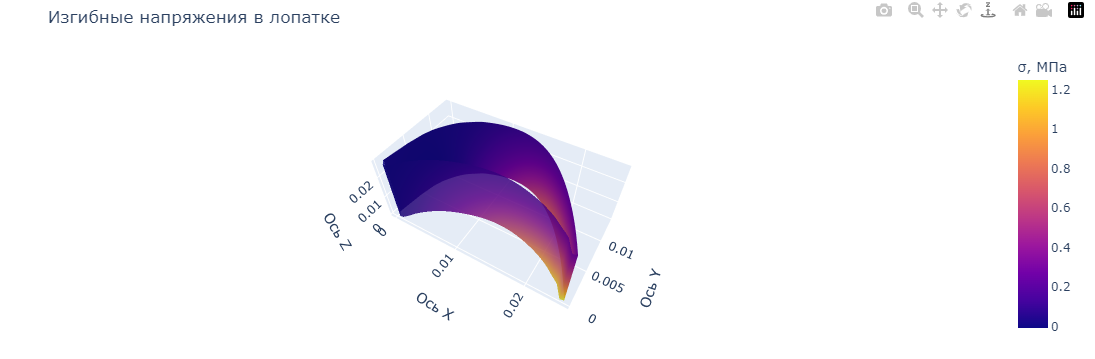